In [ ]:
if (!require(igraph)) install.packages("igraph", dependencies = TRUE) # Libraries (Change the runtime type to R in Google Colab)
library(igraph)

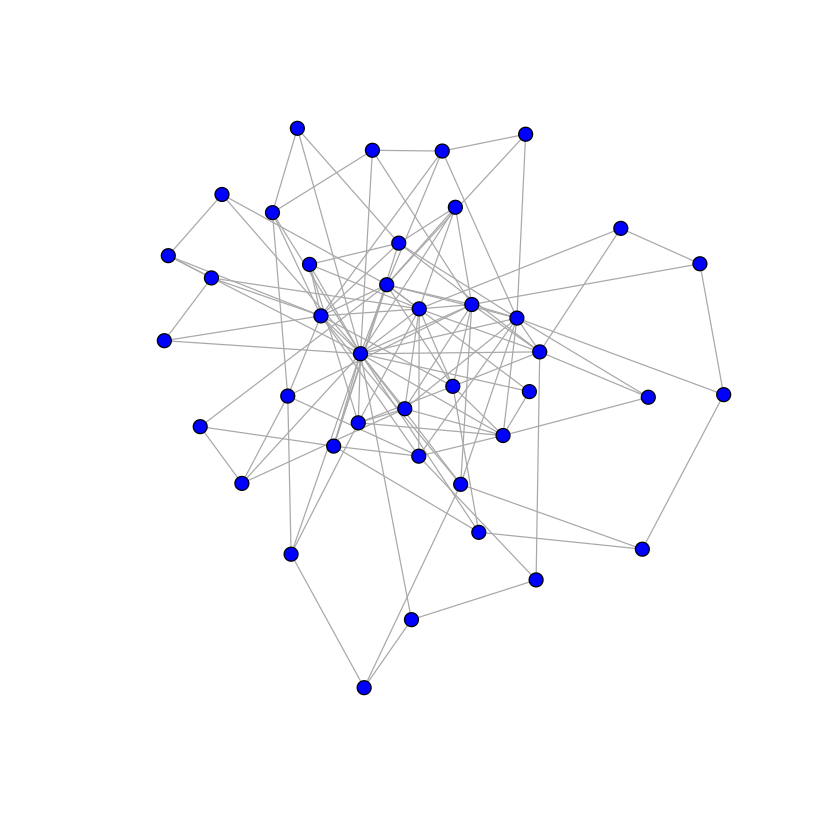

In [5]:
generate_power_law_degrees <- function(n, gamma, k_min) {
  probs <- (k_min:n)^(-gamma)
  probs <- probs / sum(probs)
  sample(k_min:n, n, replace = TRUE, prob = probs)
}

# Function for generating a scale-free graph
generate_scale_free_graph <- function(n, gamma, k_min) {
  repeat {
    degrees <- generate_power_law_degrees(n, gamma, k_min)
    if (sum(degrees) %% 2 == 0) break  # The sum of the powers must be even
  }
  g <- sample_degseq(degrees, method = "vl")
  return(g)
}

# Graph parameters
n <- 40      # Number of nodes
gamma <- 2.4
k_min <- 3   # Minimum node degree
g <- generate_scale_free_graph(n, gamma, k_min)

# Calculating node degrees
deg <- degree(g)

# Graph visualization
plot(g,
     layout = layout.fruchterman.reingold,
     vertex.size = 5,
     vertex.label = NA,
   vertex.color = "blue",
     edge.lty = 1)

# Writing a graph to the edgelist file
write.table(as_edgelist(g), "N40_y2.4.edgelist", row.names = FALSE, col.names = FALSE)